# Последовательные модели обработки текста в PyTorch

В предыдущих практических работах для анализа текстов использовались классические методы машинного обучения, основанные на представлении документов в виде набора признаков (например, CountVectorizer и TF-IDF). В этой работе мы познакомимся с последовательными моделями обработки текста, в которых учитывается порядок слов в предложении. В качестве примера будет рассмотрена архитектура LSTM, реализованная средствами библиотеки PyTorch.

В данной работе не используются распределённые вычисления Apache Spark. Это сделано намеренно: обучение рассматриваемых моделей выполняется локально и не требует обработки больших объёмов данных. Не каждая задача машинного обучения требует применения распределённых технологий, поэтому важно уметь выбирать инструмент в соответствии с поставленной задачей.


### Подготовка среды

Импортируем библиотеки, необходимые для обработки данных, подготовки текстов, построения модели и визуализации результатов.

In [1]:
import random

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set_theme(style="whitegrid", palette="deep")

## Загрузка данных

В качестве демонстрационного набора данных используется коллекция новостных статей BBC News. Каждая статья относится к одной из пяти тематик:

- Business
- Entertainment
- Politics
- Sport
- Tech

Загрузим датасет и посмотрим на его структуру.

In [2]:
df = pd.read_csv("data/bbc-text.csv")
df.head()

,category,text
0,tech,tv future in the hands of viewers with home th...
1,business,worldcom boss left books alone former worldc...
2,sport,tigers wary of farrell gamble leicester say ...
3,sport,yeading face newcastle in fa cup premiership s...
4,entertainment,ocean s twelve raids box office ocean s twelve...


In [3]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2225 entries, 0 to 2224
Data columns (total 2 columns):
 #   Column    Non-Null Count  Dtype 
---  ------    --------------  ----- 
 0   category  2225 non-null   object
 1   text      2225 non-null   object
dtypes: object(2)
memory usage: 34.9+ KB


Выведем, сколько документов относится к каждой тематике:

In [4]:
df.category.value_counts()

,count
category,
sport,511
business,510
politics,417
tech,401
entertainment,386


Рассмотрим одну статью как пример:

In [5]:
import textwrap

sample = df.sample(1).iloc[0]

print(f"Категория: {sample['category']}")

print("\nТекст:")
print("\n".join(textwrap.wrap(sample["text"], width=100)))

Категория: business

Текст:
christmas sales worst since 1981 uk retail sales fell in december  failing to meet expectations and
making it by some counts the worst christmas since 1981.  retail sales dropped by 1% on the month in
december  after a 0.6% rise in november  the office for national statistics (ons) said. the ons
revised the annual 2004 rate of growth down from the 5.9% estimated in november to 3.2%. a number of
retailers have already reported poor figures for december. clothing retailers and non-specialist
stores were the worst hit with only internet retailers showing any significant growth  according to
the ons.  the last time retailers endured a tougher christmas was 23 years previously  when sales
plunged 1.7%.  the ons echoed an earlier caution from bank of england governor mervyn king not to
read too much into the poor december figures. some analysts put a positive gloss on the figures
pointing out that the non-seasonally-adjusted figures showed a performance comparable

In [6]:
print(f"Размер датасета: {df.shape[0]} документов")
print(f"Количество тематик: {df['category'].nunique()}")

Размер датасета: 2225 документов
Количество тематик: 5


### Разделение данных

Перед построением словаря разделим данные на обучающую и тестовую выборки, так как все этапы предварительной обработки, использующие информацию о данных, должны выполняться только на основе обучающей выборки, чтобы избежать утечки информации из тестовой выборки и корректно оценить качество модели.

Используем **стратифицированное разбиение** (`stratify`). Такой способ позволяет сохранить одинаковые пропорции классов в обеих выборках.

Для небольших датасетов это особенно важно: при случайном разбиении некоторые категории могут оказаться представлены существенно хуже, что приведёт к менее объективной оценке качества модели.

При работе с крупными сбалансированными наборами данных влияние этого эффекта обычно значительно меньше.

In [7]:
from sklearn.model_selection import train_test_split

train_df, test_df = train_test_split(
    df,
    test_size=0.2,
    stratify=df["category"]
)

print(f"Обучающая выборка: {len(train_df)}")
print(f"Тестовая выборка: {len(test_df)}")

Обучающая выборка: 1780
Тестовая выборка: 445


In [8]:
distribution = (
    pd.DataFrame({
        "Train": train_df["category"].value_counts(),
        "Test": test_df["category"].value_counts()
    })
)

distribution["Train %"] = (
    distribution["Train"]
    / len(train_df)
    * 100
)

distribution["Test %"] = (
    distribution["Test"]
    / len(test_df)
    * 100
)

distribution.round(1)

,Train,Test,Train %,Test %
category,,,,
business,408,102,22.9,22.9
entertainment,309,77,17.4,17.3
politics,333,84,18.7,18.9
sport,409,102,23.0,22.9
tech,321,80,18.0,18.0


Как видно, после стратифицированного разбиения доли классов в обучающей и тестовой выборках практически совпадают.

Это позволяет сравнивать результаты моделей в одинаковых условиях и уменьшает влияние случайности при оценке качества.


### Подготовка текстов

При работе с классическими моделями машинного обучения библиотека `sklearn` автоматически строила словарь слов и формировала векторное представление документов с помощью `CountVectorizer` или `TfidfVectorizer`.

При обучении рекуррентных нейронных сетей задача несколько отличается. Нам по-прежнему необходим словарь, однако вместо формирования вектора признаков каждый документ должен быть представлен последовательностью числовых идентификаторов слов.

Прежде чем формировать словарь, необходимо разбить документы на отдельные слова. В общем случае для решения этой задачи применяют специализированные токенизаторы, но мы воспользуемся более простым подходом. Датасет содержит только англоязычные тексты, уже приведённые к нижнему регистру, поэтому достаточно удалить знаки пунктуации и разделить текст по пробелам.

In [9]:
import string

punctuation = string.punctuation.replace("-", "")
translator = str.maketrans("", "", punctuation)

def tokenize_texts(texts):
    tokenized = []

    for text in texts:
        text = text.replace("-", " ")
        text = text.translate(translator)
        tokenized.append(text.split())

    return tokenized

Выполним токенизацию обучающей выборки.

In [10]:
train_tokens = tokenize_texts(train_df["text"])

print("Исходный текст:\n")
print(train_df.iloc[0]["text"][:250] + "...")

print("\nПосле токенизации:\n")
print(train_tokens[0][:40])

Исходный текст:

news corp makes $5.4bn fox offer news corporation is seeking to buy out minority investors in fox entertainment group  its broadcasting subsidiary  for about $5.4bn (£3.7bn).  the media giant  run by rupert murdoch  owns 82% of the shares in the comp...

После токенизации:

['news', 'corp', 'makes', '54bn', 'fox', 'offer', 'news', 'corporation', 'is', 'seeking', 'to', 'buy', 'out', 'minority', 'investors', 'in', 'fox', 'entertainment', 'group', 'its', 'broadcasting', 'subsidiary', 'for', 'about', '54bn', '£37bn', 'the', 'media', 'giant', 'run', 'by', 'rupert', 'murdoch', 'owns', '82', 'of', 'the', 'shares', 'in', 'the']


После токенизации построим словарь, который сопоставляет каждому слову уникальный числовой идентификатор. Нам требуется только отображение «слово → индекс», поэтому построим его самостоятельно.

In [11]:
from collections import Counter

word_counter = Counter()
for tokens in train_tokens:
    word_counter.update(tokens)

print(f"Количество уникальных слов: {len(word_counter):,}")

pd.DataFrame(word_counter.most_common(20), columns=["Слово", "Частота"])

Количество уникальных слов: 27,517


,Слово,Частота
0,the,41904
1,to,20029
2,of,15897
3,and,14820
4,a,14647
5,in,14076
6,s,7178
7,for,7127
8,is,6790
9,that,6588


Как и в предыдущих работах, среди наиболее частотных слов можно заметить служебные слова английского языка (*the*, *to*, *of* и др.). При использовании классических моделей машинного обучения такие слова часто удаляют, а также выполняют стемминг или лемматизацию.

Для рекуррентных нейронных сетей подобная предварительная обработка применяется значительно реже, поскольку модель обучается учитывать порядок слов и их различные формы.

На практике словарь обычно ограничивают наиболее частотными словами обучающей выборки.  Это позволяет уменьшить размер слоя `Embedding` и ускорить обучение модели. Ограничим словарь наиболее частотными словами корпуса.

Для корректной работы модели добавим два специальных токена:

- `<PAD>` — используется для дополнения коротких последовательностей до фиксированной длины;
- `<UNK>` — заменяет слова, отсутствующие в словаре (в том числе слишком редкие слова, не вошедшие в ограниченный словарь).

In [12]:
VOCAB_SIZE = 10_000

print(f"Размер словаря после ограничения: {VOCAB_SIZE:,} слов")

most_common_words = word_counter.most_common(VOCAB_SIZE)
word2idx = {
    "<PAD>": 0,
    "<UNK>": 1,
}

word2idx.update({
    word: idx
    for idx, (word, _) in enumerate(most_common_words, start=2)
})

print(f"Итоговый размер словаря: {len(word2idx):,}")

pd.DataFrame(list(word2idx.items())[:10], columns=["Токен", "Индекс"])

Размер словаря после ограничения: 10,000 слов
Итоговый размер словаря: 10,002


,Токен,Индекс
0,<PAD>,0
1,<UNK>,1
2,the,2
3,to,3
4,of,4
5,and,5
6,a,6
7,in,7
8,s,8
9,for,9


In [13]:
covered = sum(
    count
    for _, count in word_counter.most_common(VOCAB_SIZE)
)

total = sum(word_counter.values())

print(f"Покрытие корпуса: {covered / total:.2%}")

Покрытие корпуса: 95.73%


Как видно, даже после ограничения словаря наиболее частотными словами сохраняется подавляющее большинство словоупотреблений корпуса. Такой подход позволяет уменьшить размер модели практически без потери информации.

Теперь каждый документ можно представить в виде последовательности числовых индексов.

In [14]:
def text_to_sequence(tokens):
    return [
        word2idx.get(token, word2idx["<UNK>"])
        for token in tokens
    ]

In [15]:
train_sequences = [
    text_to_sequence(tokens)
    for tokens in train_tokens
]

print("Токены:")
print(train_tokens[0][:20])

print("\nИндексы:")
print(train_sequences[0][:20])

Токены:
['news', 'corp', 'makes', '54bn', 'fox', 'offer', 'news', 'corporation', 'is', 'seeking', 'to', 'buy', 'out', 'minority', 'investors', 'in', 'fox', 'entertainment', 'group', 'its']

Индексы:
[170, 2897, 756, 9683, 1164, 316, 170, 2810, 10, 1694, 3, 582, 54, 2424, 852, 7, 1164, 801, 180, 43]


### Длина последовательностей

После преобразования текста в последовательности индексов возникает новая проблема: документы содержат разное количество слов.

Нейронная сеть ожидает на вход батчи одинаковой формы, поэтому перед обучением необходимо привести все последовательности к единой длине.

In [16]:
lengths = [len(sequence) for sequence in train_sequences]

pd.Series(lengths).describe()

,0
count,1780.000000
mean,390.428652
std,244.898244
min,118.000000
25%,252.000000
50%,335.000000
75%,479.000000
max,4485.000000


Оценим, как распределяются длины документов, чтобы выбрать разумное значение максимальной длины последовательности.

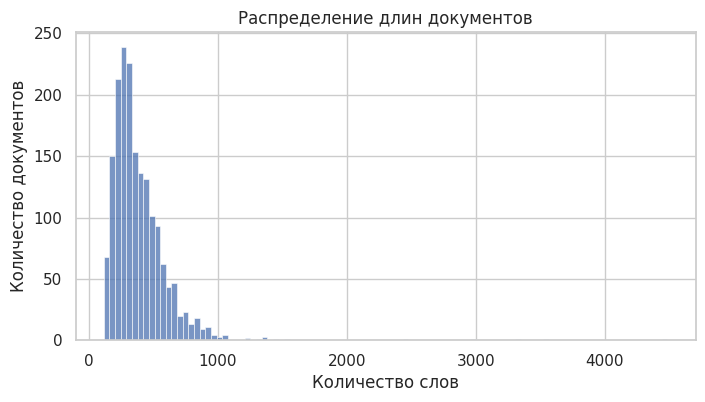

In [17]:
plt.figure(figsize=(8, 4))

sns.histplot(lengths, bins=100)

plt.xlabel("Количество слов")
plt.ylabel("Количество документов")
plt.title("Распределение длин документов")

plt.show()

Видно, что большинство документов значительно короче 1000 слов, однако встречаются и более длинные тексты. Для обучения необходимо выбрать максимальную длину последовательности. Слишком маленькое значение приведёт к потере части информации, а слишком большое — увеличит объём вычислений и может затруднить обучение модели. На практике этот параметр обычно подбирают экспериментально с учётом распределения длин документов и свойств модели.

В ходе дальнейших экспериментов были опробованы несколько значений `MAX_LENGTH`, в том числе `512`. Несмотря на то что такая длина позволяла сохранить больше текста, модель обучалась хуже. Поэтому для дальнейшей работы выбрано значение `256`.

In [18]:
MAX_LENGTH = 256

In [19]:
covered = sum(length <= MAX_LENGTH for length in lengths)

print(
    f"Полностью помещаются в выбранную длину: "
    f"{covered} из {len(lengths)} "
    f"({covered / len(lengths):.1%})"
)

Полностью помещаются в выбранную длину: 471 из 1780 (26.5%)


Более длинные документы усекаются, а более короткие дополняются специальным токеном `<PAD>`:

In [20]:
def pad_sequence(sequence, max_length, pad_value=0):
    sequence = sequence[:max_length]

    if len(sequence) < max_length:
        sequence = sequence + [pad_value] * (max_length - len(sequence))

    return sequence

Мы используем **статический паддинг**: все последовательности приводятся к одной заранее выбранной длине `MAX_LENGTH`. В практических проектах нередко применяют **динамический паддинг**. В этом случае последовательности дополняются до длины самого длинного документа внутри текущего мини-батча, что позволяет экономить память и ускорять вычисления. Обычно такую обработку выполняют средствами `DataLoader` с использованием функции `collate_fn` или готовых инструментов библиотеки PyTorch.

In [21]:
train_padded = [
    pad_sequence(sequence, MAX_LENGTH, word2idx["<PAD>"])
    for sequence in train_sequences
]

Рассмотрим результат дополнения последовательностей на примере самого короткого и самого длинного документов корпуса.

In [22]:
short_idx = min(enumerate(train_sequences), key=lambda x: len(x[1]))[0]
long_idx = max(enumerate(train_sequences), key=lambda x: len(x[1]))[0]

In [23]:
print(f"Самый короткий документ ({len(train_sequences[short_idx])}):")

print("\nДо дополнения:")
print(train_sequences[short_idx])

print("\nПосле дополнения:")
print(train_padded[short_idx])

print(f"\nСамый длинный документ ({len(train_sequences[long_idx])}):")

print(f"\nПервые {MAX_LENGTH * 2} элементов до усечения:")
print(train_sequences[long_idx][:MAX_LENGTH * 2])

print(f"\nДлина после обработки: {len(train_padded[long_idx])}")
print(train_padded[long_idx])

Самый короткий документ (118):

До дополнения:
[1, 806, 468, 1, 1, 568, 518, 523, 832, 1581, 30, 90, 88, 52, 455, 18, 1335, 1, 3619, 2350, 2185, 7, 2, 147, 1062, 7, 2443, 468, 26, 1450, 939, 175, 324, 3, 6, 3468, 4, 233, 673, 3358, 5, 2198, 456, 4932, 5, 1715, 6626, 769, 194, 77, 2, 1903, 109, 2482, 206, 1216, 1, 955, 112, 3, 156, 13, 2, 1838, 1, 1, 1, 1, 299, 4299, 183, 1, 1, 1589, 1, 1, 1, 1, 1, 1, 1, 7988, 3991, 1, 2185, 1, 1, 2484, 4461, 1, 1, 2856, 4932, 6626, 769, 1, 1, 1, 2671, 5832, 1, 3371, 190, 1, 1, 6450, 1, 3991, 29, 1, 1, 1, 1, 1, 9381, 7499, 1899, 769]

После дополнения:
[1, 806, 468, 1, 1, 568, 518, 523, 832, 1581, 30, 90, 88, 52, 455, 18, 1335, 1, 3619, 2350, 2185, 7, 2, 147, 1062, 7, 2443, 468, 26, 1450, 939, 175, 324, 3, 6, 3468, 4, 233, 673, 3358, 5, 2198, 456, 4932, 5, 1715, 6626, 769, 194, 77, 2, 1903, 109, 2482, 206, 1216, 1, 955, 112, 3, 156, 13, 2, 1838, 1, 1, 1, 1, 299, 4299, 183, 1, 1, 1589, 1, 1, 1, 1, 1, 1, 1, 7988, 3991, 1, 2185, 1, 1, 2484, 4461, 1, 1, 285

### Подготовка данных к обучению

После предварительной обработки документы представлены последовательностями одинаковой длины.

Теперь необходимо подготовить данные к обучению модели PyTorch.

Первым делом закодируем категории, так как функция потерь `CrossEntropyLoss`, которую мы будем использовать при обучении модели, ожидает, что номера классов представлены целыми числами.

In [24]:
from sklearn.preprocessing import LabelEncoder

label_encoder = LabelEncoder()
train_labels = label_encoder.fit_transform(train_df["category"])

pd.DataFrame({
    "Категория": label_encoder.classes_,
    "Код": label_encoder.transform(label_encoder.classes_)
})

,Категория,Код
0,business,0
1,entertainment,1
2,politics,2
3,sport,3
4,tech,4


Преобразуем подготовленные данные в тензоры PyTorch.

In [25]:
import torch

In [26]:
X_train = torch.tensor(train_padded, dtype=torch.long)
y_train = torch.tensor(train_labels, dtype=torch.long)

print("Размер X_train:", X_train.shape)
print("Размер y_train:", y_train.shape)

Размер X_train: torch.Size([1780, 256])
Размер y_train: torch.Size([1780])


Выведем один объект обучающей выборки:

In [27]:
print("Первая последовательность:")
print(X_train[0])

print("\nМетка класса:")
print(y_train[0])

Первая последовательность:
tensor([ 170, 2897,  756, 9683, 1164,  316,  170, 2810,   10, 1694,    3,  582,
          54, 2424,  852,    7, 1164,  801,  180,   43, 2326, 3091,    9,   53,
        9683,    1,    2,  305,  704,  331,   23, 6509, 9684, 2657, 6510,    4,
           2,  410,    7,    2,  120,  123,    3,    2, 1164,  656,  483,    5,
           2, 3415, 1762, 1164,   94, 1643,    2,  246, 2001,  170, 2897,    8,
         282,    3, 3092,   43,  242,    7,    2,   49, 3415, 1762, 1164,    8,
         353,   94, 4141,  459,   27, 1253,    1,    5,   27, 2987,  109, 1164,
        3515,   54,  250,  185,  479,  860,  162,    2, 1116,    4,    2,  316,
        2424, 1164, 1228,   24, 1214, 6511,  170, 2897,  410,    7,  453,    9,
         442, 1164,  427,   30,  539,  356,   14,    2,  282,    3,  509,  170,
        2897,    7,    2,   49,   38,   24,  514,    7,    2,  141,    8,  410,
        1108,    7,   50,  646,  474,   57, 1929,    1,    2,  221,    3, 3516,
           6,

На этом этапе каждый объект представлен последовательностью одинаковой длины и соответствующей ей меткой класса.

### Dataset и DataLoader

Подготовленные данные удобно объединить в объект `Dataset`, который хранит признаки и соответствующие им метки классов.

Для формирования мини-батчей во время обучения воспользуемся уже знакомым классом `DataLoader`.

In [28]:
from torch.utils.data import TensorDataset

train_dataset = TensorDataset(X_train, y_train)

In [29]:
train_dataset[0]

(tensor([ 170, 2897,  756, 9683, 1164,  316,  170, 2810,   10, 1694,    3,  582,
           54, 2424,  852,    7, 1164,  801,  180,   43, 2326, 3091,    9,   53,
         9683,    1,    2,  305,  704,  331,   23, 6509, 9684, 2657, 6510,    4,
            2,  410,    7,    2,  120,  123,    3,    2, 1164,  656,  483,    5,
            2, 3415, 1762, 1164,   94, 1643,    2,  246, 2001,  170, 2897,    8,
          282,    3, 3092,   43,  242,    7,    2,   49, 3415, 1762, 1164,    8,
          353,   94, 4141,  459,   27, 1253,    1,    5,   27, 2987,  109, 1164,
         3515,   54,  250,  185,  479,  860,  162,    2, 1116,    4,    2,  316,
         2424, 1164, 1228,   24, 1214, 6511,  170, 2897,  410,    7,  453,    9,
          442, 1164,  427,   30,  539,  356,   14,    2,  282,    3,  509,  170,
         2897,    7,    2,   49,   38,   24,  514,    7,    2,  141,    8,  410,
         1108,    7,   50,  646,  474,   57, 1929,    1,    2,  221,    3, 3516,
            6, 1304,  657,  

Во время обучения модели данные обычно обрабатываются мини-батчами. Для их формирования воспользуемся уже знакомым классом `DataLoader`.

In [30]:
from torch.utils.data import DataLoader

BATCH_SIZE = 64

train_loader = DataLoader(
    train_dataset,
    batch_size=BATCH_SIZE,
    shuffle=True
)

In [31]:
X_batch, y_batch = next(iter(train_loader))

print(X_batch.shape)
print(y_batch.shape)

torch.Size([64, 256])
torch.Size([64])


Каждый мини-батч содержит несколько документов одинаковой длины и соответствующие им метки классов. Именно такие батчи будут последовательно подаваться на вход нейронной сети во время обучения.

### Построение модели

Подготовка данных завершена. Теперь можно перейти к созданию рекуррентной нейронной сети для классификации текстов.

Рекуррентные сети работают с последовательностями элементов, анализируя их шаг за шагом. Мы воспользуемся архитектурой **LSTM (Long Short-Term Memory)**. Она была разработана как развитие классических рекуррентных сетей и позволяет значительно лучше учитывать информацию из предыдущих частей последовательности при обработке длинных текстов.

Первым слоем модели станет `Embedding`, который преобразует индексы слов в плотные векторные представления, после чего последовательность будет обработана слоем `LSTM`.

In [32]:
EMBEDDING_DIM = 128
HIDDEN_DIM = 128
NUM_CLASSES = len(label_encoder.classes_)

In [33]:
import torch.nn as nn


class LSTMClassifier(nn.Module):

    def __init__(
        self,
        vocab_size,
        embedding_dim,
        hidden_dim,
        num_classes,
        padding_idx=0,
        bidirectional=False
    ):
        super().__init__()

        self.embedding = nn.Embedding(
            num_embeddings=vocab_size,
            embedding_dim=embedding_dim,
            padding_idx=padding_idx
        )

        self.lstm = nn.LSTM(
            input_size=embedding_dim,
            hidden_size=hidden_dim,
            batch_first=True,
            bidirectional=bidirectional
        )

        if self.lstm.bidirectional:
            raise NotImplementedError(
                "Реализуйте корректный расчет входной размерности для nn.Linear "
                "при использовании двунаправленной (bidirectional) LSTM!"
            )
        else:
            classifier_input_dim = hidden_dim

        self.classifier = nn.Linear(
            classifier_input_dim,
            num_classes
        )

    def forward(self, x):
        x = self.embedding(x)

        _, (hidden, _) = self.lstm(x)

        if self.lstm.bidirectional:
            raise NotImplementedError(
                "Реализуйте извлечение и объединение скрытых состояний "
                "для двунаправленной (bidirectional) LSTM в методе forward!"
            )
        else:
            final_state = hidden[-1]

        logits = self.classifier(final_state)

        return logits

Параметр `padding_idx=word2idx["<PAD>"]` сообщает слою `Embedding`, что индекс `<PAD>` является служебным. Для него не обновляются веса во время обучения, поэтому добавленные при паддинге токены не влияют на обучение модели.

Слой `LSTM` возвращает два результата:

- последовательность скрытых состояний (`output`);
- финальные скрытые состояния (`hidden`).

Для классификации в нашем случае используется именно скрытое состояние последнего слоя LSTM (`hidden[-1]`). В однонаправленной архитектуре оно содержит информацию обо всей обработанной последовательности.

Параметр `batch_first=True` меняет порядок измерений только для последовательности выходных состояний (`output`). Размерность тензора `hidden` от этого не изменяется.

In [34]:
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print(f"Используемое устройство: {device}")

Используемое устройство: cpu


In [35]:
model = LSTMClassifier(
    vocab_size=len(word2idx),
    embedding_dim=EMBEDDING_DIM,
    hidden_dim=HIDDEN_DIM,
    num_classes=NUM_CLASSES,
    padding_idx=word2idx["<PAD>"],
    bidirectional=False
).to(device)

model

LSTMClassifier(
  (embedding): Embedding(10002, 128, padding_idx=0)
  (lstm): LSTM(128, 128, batch_first=True)
  (classifier): Linear(in_features=128, out_features=5, bias=True)
)

Модель состоит из трех основных частей:

- `Embedding` преобразует индексы слов в обучаемые плотные векторы фиксированной размерности;
- `LSTM` последовательно анализирует текст, постепенно накапливая информацию о прочитанной последовательности;
- `Linear` использует полученное представление для предсказания одной из тематик документа.

In [36]:
X_batch, _ = next(iter(train_loader))
X_batch = X_batch.to(device)

with torch.no_grad():
    output = model(X_batch)

print(output.shape)

torch.Size([64, 5])


Для каждого документа модель вычислила оценки принадлежности к каждому из пяти классов. Окончательный выбор наиболее вероятной тематики будет выполняться по максимальному из этих значений.

### Подготовка тестовой выборки

Перед обучением модели осталось подготовить тестовую выборку. Она понадобится для оценки качества после каждой эпохи обучения.

Все параметры предварительной обработки уже определены по обучающей выборке:

- способ токенизации;
- словарь слов;
- максимальная длина последовательности;
- кодирование категорий.

Применяем всю последовательность действий:

In [37]:
# Токенизация
test_tokens = tokenize_texts(test_df["text"])

In [38]:
# Кодирование текстов
test_sequences = [
    text_to_sequence(tokens)
    for tokens in test_tokens
]

In [39]:
# Дополнение последовательностей
test_padded = [
    pad_sequence(sequence, MAX_LENGTH)
    for sequence in test_sequences
]

In [40]:
# Кодирование категорий
test_labels = label_encoder.transform(test_df["category"])

In [41]:
# Тензоры и загрузчики
X_test = torch.tensor(test_padded, dtype=torch.long)
y_test = torch.tensor(test_labels, dtype=torch.long)

test_dataset = TensorDataset(X_test, y_test)

test_loader = DataLoader(
    test_dataset,
    batch_size=BATCH_SIZE,
    shuffle=False
)

### Обучение модели

В процессе обучения будем отслеживать значение функции потерь и долю правильных ответов на обучающей и тестовой выборках.

Сначала зададим параметры обучения, функцию потерь и алгоритм оптимизации.

In [42]:
LEARNING_RATE = 0.001
EPOCHS = 20

criterion = nn.CrossEntropyLoss()

optimizer = torch.optim.Adam(
    model.parameters(),
    lr=LEARNING_RATE
)

In [43]:
def train_epoch(model, dataloader, criterion, optimizer, device):

    model.train()

    total_loss = 0
    correct = 0
    total = 0

    for X_batch, y_batch in dataloader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        torch.nn.utils.clip_grad_norm_(model.parameters(), 1.0)
        optimizer.step()
        total_loss += loss.item() * X_batch.size(0)
        predictions = outputs.argmax(dim=1)
        correct += (predictions == y_batch).sum().item()
        total += y_batch.size(0)

    return (total_loss / total, correct / total)

In [44]:
def evaluate(model, dataloader, criterion, device):

    model.eval()

    total_loss = 0
    correct = 0
    total = 0

    with torch.no_grad():
        for X_batch, y_batch in dataloader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            total_loss += loss.item() * X_batch.size(0)
            predictions = outputs.argmax(dim=1)
            correct += (predictions == y_batch).sum().item()
            total += y_batch.size(0)

    return (total_loss / total, correct / total)

In [45]:
trainable_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f"Количество обучаемых параметров: {trainable_params:,}")

Количество обучаемых параметров: 1,412,997


Запускаем обучение модели. Во время обучения после каждой эпохи будем вычислять значение функции потерь и точность как на обучающей, так и на тестовой выборке.

Кроме того, будем сохранять веса модели, показавшей наилучшую точность на тестовой выборке. В дальнейшем именно эта версия модели будет использоваться для оценки качества и анализа результатов.

In [46]:
history = {
    "train_loss": [],
    "train_acc": [],
    "test_loss": [],
    "test_acc": [],
}

best_acc = 0.0

for epoch in range(EPOCHS):

    train_loss, train_acc = train_epoch(
        model,
        train_loader,
        criterion,
        optimizer,
        device
    )

    test_loss, test_acc = evaluate(
        model,
        test_loader,
        criterion,
        device
    )

    history["train_loss"].append(train_loss)
    history["train_acc"].append(train_acc)
    history["test_loss"].append(test_loss)
    history["test_acc"].append(test_acc)

    if test_acc > best_acc:
        best_acc = test_acc
        torch.save(model.state_dict(), "best_model.pth")

    print(
        f"Эпоха {epoch + 1:>2}/{EPOCHS} | "
        f"Train Loss: {train_loss:.4f} | "
        f"Train Acc: {train_acc:.3f} | "
        f"Test Loss: {test_loss:.4f} | "
        f"Test Acc: {test_acc:.3f}"
    )

Эпоха  1/20 | Train Loss: 1.5910 | Train Acc: 0.272 | Test Loss: 1.5719 | Test Acc: 0.272
Эпоха  2/20 | Train Loss: 1.4606 | Train Acc: 0.402 | Test Loss: 1.4541 | Test Acc: 0.357
Эпоха  3/20 | Train Loss: 1.3036 | Train Acc: 0.475 | Test Loss: 1.4405 | Test Acc: 0.342
Эпоха  4/20 | Train Loss: 1.2179 | Train Acc: 0.542 | Test Loss: 1.3539 | Test Acc: 0.422
Эпоха  5/20 | Train Loss: 1.0536 | Train Acc: 0.600 | Test Loss: 1.3384 | Test Acc: 0.485
Эпоха  6/20 | Train Loss: 0.9202 | Train Acc: 0.653 | Test Loss: 1.2779 | Test Acc: 0.526
Эпоха  7/20 | Train Loss: 0.7894 | Train Acc: 0.716 | Test Loss: 1.1244 | Test Acc: 0.571
Эпоха  8/20 | Train Loss: 0.7455 | Train Acc: 0.752 | Test Loss: 1.1343 | Test Acc: 0.575
Эпоха  9/20 | Train Loss: 0.6118 | Train Acc: 0.792 | Test Loss: 1.0038 | Test Acc: 0.647
Эпоха 10/20 | Train Loss: 0.5456 | Train Acc: 0.822 | Test Loss: 1.0524 | Test Acc: 0.611
Эпоха 11/20 | Train Loss: 0.5044 | Train Acc: 0.848 | Test Loss: 1.1096 | Test Acc: 0.654
Эпоха 12/2

Качество работы модели зависит не только от архитектуры сети, но и от параметров предварительной обработки текстов. Ограничение словаря, выбор максимальной длины последовательности и корректная подготовка обучающей выборки существенно влияют на итоговую точность.

Кроме того, даже при одинаковой архитектуре и одинаковых гиперпараметрах результаты разных запусков могут отличаться. Это связано со случайной инициализацией весов модели и случайным порядком формирования мини-батчей, поэтому при сравнении моделей обычно ориентируются не на один запуск, а на несколько экспериментов.

### Анализ результатов обучения
Во время обучения мы сохраняли модель, показавшую наилучшее качество на тестовой выборке.

Загрузим её и более подробно оценим результаты работы.

In [47]:
model.load_state_dict(torch.load("best_model.pth"))
model.eval()

LSTMClassifier(
  (embedding): Embedding(10002, 128, padding_idx=0)
  (lstm): LSTM(128, 128, batch_first=True)
  (classifier): Linear(in_features=128, out_features=5, bias=True)
)

Во время обучения после каждой эпохи мы сохраняли значения функции потерь (`Loss`) и точности классификации (`Accuracy`) как на обучающей, так и на тестовой выборках.

Построим графики изменения этих величин. Они позволяют оценить скорость обучения модели, проследить, как меняется качество на разных выборках, а также заметить признаки недообучения или переобучения.

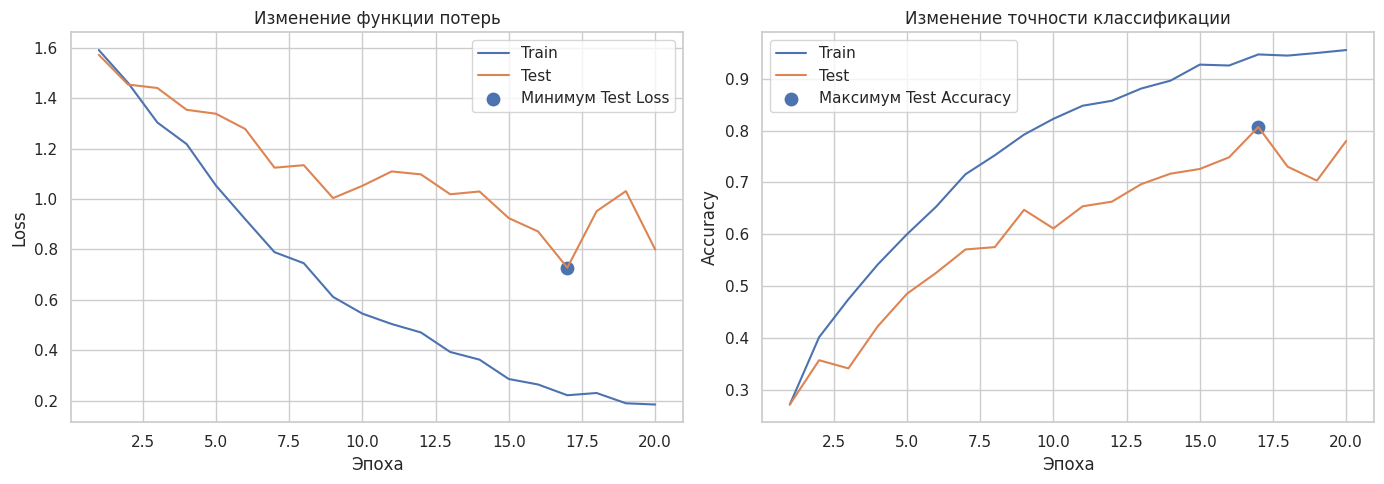

In [48]:
fig, axes = plt.subplots(
    nrows=1,
    ncols=2,
    figsize=(14, 5)
)

# ---------- Loss ----------

sns.lineplot(
    ax=axes[0],
    x=range(1, EPOCHS + 1),
    y=history["train_loss"],
    label="Train"
)

sns.lineplot(
    ax=axes[0],
    x=range(1, EPOCHS + 1),
    y=history["test_loss"],
    label="Test"
)

best_loss_epoch = np.argmin(history["test_loss"])

axes[0].scatter(
    best_loss_epoch + 1,
    history["test_loss"][best_loss_epoch],
    s=80,
    label="Минимум Test Loss"
)

axes[0].set_title("Изменение функции потерь")
axes[0].set_xlabel("Эпоха")
axes[0].set_ylabel("Loss")
axes[0].legend()

# ---------- Accuracy ----------

sns.lineplot(
    ax=axes[1],
    x=range(1, EPOCHS + 1),
    y=history["train_acc"],
    label="Train"
)

sns.lineplot(
    ax=axes[1],
    x=range(1, EPOCHS + 1),
    y=history["test_acc"],
    label="Test"
)

best_acc_epoch = np.argmax(history["test_acc"])

axes[1].scatter(
    best_acc_epoch + 1,
    history["test_acc"][best_acc_epoch],
    s=80,
    label="Максимум Test Accuracy"
)

axes[1].set_title("Изменение точности классификации")
axes[1].set_xlabel("Эпоха")
axes[1].set_ylabel("Accuracy")
axes[1].legend()

plt.tight_layout()
plt.show()

Полученные графики показывают, что по мере обучения качество модели на обучающей выборке продолжает расти. При этом качество на тестовой выборке может перестать улучшаться или даже начать снижаться. В такой ситуации обычно сохраняют модель, показавшую лучший результат на тестовой выборке, а не обязательно модель после последней эпохи обучения.

Именно поэтому в процессе обучения мы сохраняли веса модели, соответствующие лучшей эпохе.

### Оценка качества модели

Рассчитаем `classification_report` для тестовой выборки.

In [49]:
from sklearn.metrics import classification_report

all_preds = []
all_labels = []

with torch.no_grad():
    for texts, labels in test_loader:
        outputs = model(texts)
        preds = outputs.argmax(dim=1)

        all_preds.extend(preds.cpu().numpy())
        all_labels.extend(labels.cpu().numpy())

In [50]:
print(
    classification_report(
        all_labels,
        all_preds,
        target_names=label_encoder.classes_,
        digits=3
    )
)

               precision    recall  f1-score   support

     business      0.784     0.784     0.784       102
entertainment      0.843     0.766     0.803        77
     politics      0.780     0.762     0.771        84
        sport      0.914     0.941     0.928       102
         tech      0.698     0.750     0.723        80

     accuracy                          0.807       445
    macro avg      0.804     0.801     0.802       445
 weighted avg      0.808     0.807     0.807       445



Определим, какие категории модель чаще всего путает между собой.

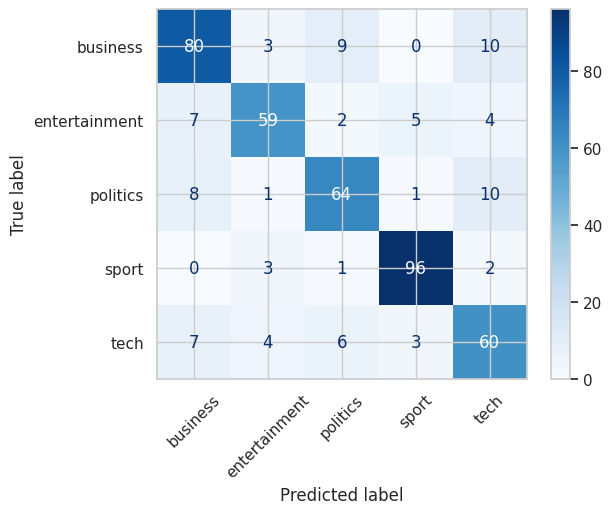

In [51]:
from sklearn.metrics import ConfusionMatrixDisplay

ConfusionMatrixDisplay.from_predictions(
    y_true=all_labels,
    y_pred=all_preds,
    display_labels=label_encoder.classes_,
    xticks_rotation=45,
    cmap="Blues"
)

plt.show()

### Анализ ошибок модели

Рассмотрим несколько документов, на которых модель ошиблась.

In [52]:
mistakes = []

for i, (true_label, pred_label) in enumerate(zip(all_labels, all_preds)):
    if true_label != pred_label:
        mistakes.append(i)

print(f"Количество ошибок: {len(mistakes)}")

Количество ошибок: 86


In [53]:
sample_size = min(5, len(mistakes))

for idx in random.sample(mistakes, sample_size):

    print("=" * 100 + '\n')

    print(f"Истинный класс : {label_encoder.classes_[all_labels[idx]]}")
    print(f"Предсказание   : {label_encoder.classes_[all_preds[idx]]}")

    print("\nТекст:\n")

    print(
        textwrap.fill(
            test_df.iloc[idx]["text"][:1000],
            width=100
        ),
        end='\n\n'
    )


Истинный класс : tech
Предсказание   : politics

Текст:

local net tv takes off in austria an austrian village is testing technology that could represent the
future of television.  the people of engerwitzdorf are filming  editing and producing their own
regional news channel. the channel covers local politics  sports  events and anything that residents
want to film and are prepared to upload for others to watch on pcs. the pilot has been so successful
that telekom austria is now considering setting up other projects elsewhere.   it s growing
unbelievably fast   said rudolf fischer  head of telekom austria s fixed line division. the trial of
buntes fernsehen (multi-coloured tv) was started in late 2004 and creates a net-based tv station run
by the 8 000 residents of engerwitzdorf. the hardware and software to turn video footage into edited
programmes has been provided by telekom austria but this equipment  following training  has been
turned over to the villagers. any video programme c

### Итоги

В ходе работы мы познакомились с одним из вариантов обработки текстов с помощью рекуррентных нейронных сетей.

Несмотря на то, что сегодня архитектуры на основе трансформеров используются значительно чаще, понимание принципов работы рекуррентных моделей остаётся важной частью подготовки специалиста по машинному обучению.